# Mobile App User Engagement & Retention Analysis

This project analyzes mobile app user behavior to understand engagement, conversion funnels, retention, and experiment performance. The analysis combines product analytics, cohort analysis, A/B testing, and predictive modeling to identify opportunities for improving user activation and retention.

In [1]:
# PHASE 1: SETUP AND DATA GENERATION

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print("Libraries loaded successfully.")

# ---------------------------------------------------------
# Create realistic synthetic mobile-app user data
# ---------------------------------------------------------

n_users = 20000

users = pd.DataFrame({
    "user_id": np.arange(1, n_users + 1),
    "signup_date": pd.to_datetime("2026-01-01") +
                   pd.to_timedelta(rng.integers(0, 90, n_users), unit="D"),
    "platform": rng.choice(
        ["iOS", "Android"],
        n_users,
        p=[0.47, 0.53]
    ),
    "acquisition_channel": rng.choice(
        ["Organic", "Paid Search", "Social", "Referral", "Email"],
        n_users,
        p=[0.30, 0.23, 0.20, 0.17, 0.10]
    ),
    "country": rng.choice(
        ["United States", "United Kingdom", "Canada", "Germany", "Australia"],
        n_users,
        p=[0.48, 0.16, 0.14, 0.12, 0.10]
    ),
    "experiment_group": rng.choice(
        ["Control", "Treatment"],
        n_users,
        p=[0.50, 0.50]
    )
})

# ---------------------------------------------------------
# Simulate onboarding behavior
# ---------------------------------------------------------

users["onboarding_started"] = rng.binomial(1, 0.92, n_users)

completion_probability = np.where(
    users["experiment_group"].eq("Treatment"),
    0.82,
    0.76
)

users["onboarding_completed"] = (
    users["onboarding_started"] *
    rng.binomial(1, completion_probability)
)

# ---------------------------------------------------------
# Simulate first key product action
# ---------------------------------------------------------

activation_probability = (
    0.30
    + users["onboarding_completed"] * 0.38
    + users["acquisition_channel"].map({
        "Organic": 0.06,
        "Referral": 0.08,
        "Email": 0.04,
        "Paid Search": 0.00,
        "Social": -0.02
    }).astype(float)
)

activation_probability = np.clip(
    activation_probability,
    0.05,
    0.90
)

users["activated"] = rng.binomial(
    1,
    activation_probability
)

# ---------------------------------------------------------
# Simulate engagement metrics
# ---------------------------------------------------------

users["sessions_30d"] = np.maximum(
    1,
    rng.poisson(
        3
        + users["activated"] * 7
        + users["onboarding_completed"] * 2
    )
)

users["features_used"] = np.clip(
    rng.poisson(
        1.5
        + users["activated"] * 2.8
        + users["sessions_30d"] * 0.08
    ),
    1,
    12
)

users["avg_session_minutes"] = np.maximum(
    1,
    rng.normal(
        5
        + users["activated"] * 4
        + users["features_used"] * 0.45,
        2.2
    )
).round(2)

# ---------------------------------------------------------
# Simulate retention
# ---------------------------------------------------------

retention_7_probability = (
    0.12
    + users["activated"] * 0.28
    + users["onboarding_completed"] * 0.10
    + np.minimum(users["sessions_30d"], 15) * 0.012
)

retention_7_probability = np.clip(
    retention_7_probability,
    0.05,
    0.88
)

users["retained_day_7"] = rng.binomial(
    1,
    retention_7_probability
)

retention_30_probability = (
    0.06
    + users["activated"] * 0.20
    + users["retained_day_7"] * 0.35
    + np.minimum(users["features_used"], 8) * 0.018
)

retention_30_probability = np.clip(
    retention_30_probability,
    0.03,
    0.85
)

users["retained_day_30"] = rng.binomial(
    1,
    retention_30_probability
)

# ---------------------------------------------------------
# Simulate subscription conversion
# ---------------------------------------------------------

subscription_probability = (
    0.025
    + users["activated"] * 0.08
    + users["retained_day_30"] * 0.16
    + (users["experiment_group"] == "Treatment") * 0.012
)

subscription_probability = np.clip(
    subscription_probability,
    0.01,
    0.50
)

users["subscribed"] = rng.binomial(
    1,
    subscription_probability
)

# ---------------------------------------------------------
# Revenue
# ---------------------------------------------------------

users["revenue_30d"] = np.where(
    users["subscribed"] == 1,
    rng.gamma(shape=2.5, scale=12, size=n_users),
    0
).round(2)

# ---------------------------------------------------------
# Create last activity date for cohort/retention analysis
# ---------------------------------------------------------

activity_days = np.where(
    users["retained_day_30"] == 1,
    rng.integers(30, 61, n_users),
    np.where(
        users["retained_day_7"] == 1,
        rng.integers(7, 30, n_users),
        rng.integers(0, 7, n_users)
    )
)

users["last_activity_date"] = (
    users["signup_date"] +
    pd.to_timedelta(activity_days, unit="D")
)

# ---------------------------------------------------------
# Basic validation
# ---------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET CREATED")
print("=" * 60)

print(f"Rows: {users.shape[0]:,}")
print(f"Columns: {users.shape[1]}")
print(f"Unique users: {users['user_id'].nunique():,}")
print(f"Signup period: {users['signup_date'].min().date()} to {users['signup_date'].max().date()}")

print("\nColumns:")
print(users.columns.tolist())

print("\nMissing values:")
print(users.isnull().sum())

print("\nSample:")
display(users.head())

print("\n" + "=" * 60)
print("INITIAL PRODUCT METRICS")
print("=" * 60)

print(f"Onboarding start rate: {users['onboarding_started'].mean():.2%}")
print(f"Onboarding completion rate: {users['onboarding_completed'].mean():.2%}")
print(f"Activation rate: {users['activated'].mean():.2%}")
print(f"Day 7 retention: {users['retained_day_7'].mean():.2%}")
print(f"Day 30 retention: {users['retained_day_30'].mean():.2%}")
print(f"Subscription rate: {users['subscribed'].mean():.2%}")
print(f"30-day revenue: ${users['revenue_30d'].sum():,.2f}")

print("\nPhase 1 complete.")

Libraries loaded successfully.

DATASET CREATED
Rows: 20,000
Columns: 17
Unique users: 20,000
Signup period: 2026-01-01 to 2026-03-31

Columns:
['user_id', 'signup_date', 'platform', 'acquisition_channel', 'country', 'experiment_group', 'onboarding_started', 'onboarding_completed', 'activated', 'sessions_30d', 'features_used', 'avg_session_minutes', 'retained_day_7', 'retained_day_30', 'subscribed', 'revenue_30d', 'last_activity_date']

Missing values:
user_id                 0
signup_date             0
platform                0
acquisition_channel     0
country                 0
experiment_group        0
onboarding_started      0
onboarding_completed    0
activated               0
sessions_30d            0
features_used           0
avg_session_minutes     0
retained_day_7          0
retained_day_30         0
subscribed              0
revenue_30d             0
last_activity_date      0
dtype: int64

Sample:


,user_id,signup_date,platform,acquisition_channel,country,experiment_group,onboarding_started,onboarding_completed,activated,sessions_30d,features_used,avg_session_minutes,retained_day_7,retained_day_30,subscribed,revenue_30d,last_activity_date
0,1,2026-01-09,Android,Paid Search,Germany,Control,1,1,1,12,3,10.11,0,0,0,0.00,2026-01-12
1,2,2026-03-11,Android,Paid Search,United States,Control,1,1,1,15,6,11.19,0,1,1,61.54,2026-04-24
2,3,2026-02-28,iOS,Email,United Kingdom,Treatment,1,0,0,1,2,9.45,0,0,0,0.00,2026-03-02
3,4,2026-02-09,iOS,Organic,United States,Control,1,1,1,11,10,15.26,1,1,0,0.00,2026-03-31
4,5,2026-02-08,iOS,Organic,United Kingdom,Control,0,0,1,9,6,6.76,1,0,1,31.19,2026-02-15



INITIAL PRODUCT METRICS
Onboarding start rate: 91.86%
Onboarding completion rate: 72.83%
Activation rate: 60.51%
Day 7 retention: 46.06%
Day 30 retention: 40.90%
Subscription rate: 14.56%
30-day revenue: $86,599.97

Phase 1 complete.


## Phase 2 — Data Quality and Product KPI Analysis

This phase validates the dataset and establishes baseline product metrics across the user lifecycle, from onboarding and activation through retention, subscription, and revenue.

In [2]:
# PHASE 2: DATA QUALITY AND PRODUCT KPI ANALYSIS

print("=" * 65)
print("DATA QUALITY CHECK")
print("=" * 65)

# ---------------------------------------------------------
# Duplicate and validity checks
# ---------------------------------------------------------

duplicate_users = users["user_id"].duplicated().sum()

binary_columns = [
    "onboarding_started",
    "onboarding_completed",
    "activated",
    "retained_day_7",
    "retained_day_30",
    "subscribed"
]

invalid_binary_values = {
    col: (~users[col].isin([0, 1])).sum()
    for col in binary_columns
}

print(f"Duplicate user IDs: {duplicate_users:,}")
print(f"Missing values: {users.isnull().sum().sum():,}")
print(f"Negative sessions: {(users['sessions_30d'] < 0).sum():,}")
print(f"Negative revenue: {(users['revenue_30d'] < 0).sum():,}")
print(f"Invalid binary values: {sum(invalid_binary_values.values()):,}")

# Logical consistency checks
completed_without_start = (
    (users["onboarding_completed"] == 1) &
    (users["onboarding_started"] == 0)
).sum()

print(f"Completed onboarding without starting: {completed_without_start:,}")

# ---------------------------------------------------------
# Core product funnel
# ---------------------------------------------------------

total_users = len(users)
started = users["onboarding_started"].sum()
completed = users["onboarding_completed"].sum()
activated = users["activated"].sum()
retained_7 = users["retained_day_7"].sum()
retained_30 = users["retained_day_30"].sum()
subscribed = users["subscribed"].sum()

funnel = pd.DataFrame({
    "stage": [
        "Signed Up",
        "Started Onboarding",
        "Completed Onboarding",
        "Activated",
        "Retained Day 7",
        "Retained Day 30",
        "Subscribed"
    ],
    "users": [
        total_users,
        started,
        completed,
        activated,
        retained_7,
        retained_30,
        subscribed
    ]
})

funnel["% of signups"] = (
    funnel["users"] / total_users * 100
).round(2)

funnel["step_conversion_%"] = (
    funnel["users"] /
    funnel["users"].shift(1) * 100
).round(2)

funnel.loc[0, "step_conversion_%"] = 100

print("\n" + "=" * 65)
print("PRODUCT FUNNEL")
print("=" * 65)

display(funnel)

# ---------------------------------------------------------
# Overall KPIs
# ---------------------------------------------------------

total_revenue = users["revenue_30d"].sum()
arpu = total_revenue / total_users
arppu = (
    users.loc[users["subscribed"] == 1, "revenue_30d"].mean()
)

kpis = pd.DataFrame({
    "Metric": [
        "Total Users",
        "Onboarding Start Rate",
        "Onboarding Completion Rate",
        "Activation Rate",
        "Day 7 Retention",
        "Day 30 Retention",
        "Subscription Rate",
        "Average Sessions per User",
        "Average Features Used",
        "Average Session Duration",
        "Total 30-Day Revenue",
        "ARPU",
        "Average Revenue per Subscriber"
    ],
    "Value": [
        f"{total_users:,}",
        f"{users['onboarding_started'].mean():.2%}",
        f"{users['onboarding_completed'].mean():.2%}",
        f"{users['activated'].mean():.2%}",
        f"{users['retained_day_7'].mean():.2%}",
        f"{users['retained_day_30'].mean():.2%}",
        f"{users['subscribed'].mean():.2%}",
        f"{users['sessions_30d'].mean():.2f}",
        f"{users['features_used'].mean():.2f}",
        f"{users['avg_session_minutes'].mean():.2f} min",
        f"${total_revenue:,.2f}",
        f"${arpu:.2f}",
        f"${arppu:.2f}"
    ]
})

print("\n" + "=" * 65)
print("CORE PRODUCT KPIs")
print("=" * 65)

display(kpis)

# ---------------------------------------------------------
# Acquisition channel performance
# ---------------------------------------------------------

channel_performance = (
    users.groupby("acquisition_channel")
    .agg(
        users=("user_id", "count"),
        activation_rate=("activated", "mean"),
        day_7_retention=("retained_day_7", "mean"),
        day_30_retention=("retained_day_30", "mean"),
        subscription_rate=("subscribed", "mean"),
        avg_sessions=("sessions_30d", "mean"),
        total_revenue=("revenue_30d", "sum")
    )
    .reset_index()
)

for col in [
    "activation_rate",
    "day_7_retention",
    "day_30_retention",
    "subscription_rate"
]:
    channel_performance[col] = (
        channel_performance[col] * 100
    ).round(2)

channel_performance["avg_sessions"] = (
    channel_performance["avg_sessions"].round(2)
)

channel_performance["total_revenue"] = (
    channel_performance["total_revenue"].round(2)
)

channel_performance["revenue_per_user"] = (
    channel_performance["total_revenue"] /
    channel_performance["users"]
).round(2)

channel_performance = channel_performance.sort_values(
    "activation_rate",
    ascending=False
)

print("\n" + "=" * 65)
print("ACQUISITION CHANNEL PERFORMANCE")
print("=" * 65)

display(channel_performance)

# ---------------------------------------------------------
# Platform performance
# ---------------------------------------------------------

platform_performance = (
    users.groupby("platform")
    .agg(
        users=("user_id", "count"),
        activation_rate=("activated", "mean"),
        day_30_retention=("retained_day_30", "mean"),
        subscription_rate=("subscribed", "mean"),
        avg_sessions=("sessions_30d", "mean"),
        revenue=("revenue_30d", "sum")
    )
    .reset_index()
)

for col in [
    "activation_rate",
    "day_30_retention",
    "subscription_rate"
]:
    platform_performance[col] = (
        platform_performance[col] * 100
    ).round(2)

platform_performance["avg_sessions"] = (
    platform_performance["avg_sessions"].round(2)
)

platform_performance["revenue"] = (
    platform_performance["revenue"].round(2)
)

print("\n" + "=" * 65)
print("PLATFORM PERFORMANCE")
print("=" * 65)

display(platform_performance)

# ---------------------------------------------------------
# Activation impact
# ---------------------------------------------------------

activation_impact = (
    users.groupby("activated")
    .agg(
        users=("user_id", "count"),
        avg_sessions=("sessions_30d", "mean"),
        avg_features=("features_used", "mean"),
        day_7_retention=("retained_day_7", "mean"),
        day_30_retention=("retained_day_30", "mean"),
        subscription_rate=("subscribed", "mean"),
        avg_revenue=("revenue_30d", "mean")
    )
    .reset_index()
)

activation_impact["user_type"] = activation_impact["activated"].map({
    0: "Not Activated",
    1: "Activated"
})

for col in [
    "day_7_retention",
    "day_30_retention",
    "subscription_rate"
]:
    activation_impact[col] = (
        activation_impact[col] * 100
    ).round(2)

for col in [
    "avg_sessions",
    "avg_features",
    "avg_revenue"
]:
    activation_impact[col] = activation_impact[col].round(2)

activation_impact = activation_impact[
    [
        "user_type",
        "users",
        "avg_sessions",
        "avg_features",
        "day_7_retention",
        "day_30_retention",
        "subscription_rate",
        "avg_revenue"
    ]
]

print("\n" + "=" * 65)
print("ACTIVATION IMPACT")
print("=" * 65)

display(activation_impact)

# ---------------------------------------------------------
# Automatically identify major findings
# ---------------------------------------------------------

best_channel = channel_performance.iloc[0]

activated_row = activation_impact[
    activation_impact["user_type"] == "Activated"
].iloc[0]

nonactivated_row = activation_impact[
    activation_impact["user_type"] == "Not Activated"
].iloc[0]

retention_lift = (
    activated_row["day_30_retention"] -
    nonactivated_row["day_30_retention"]
)

print("\n" + "=" * 65)
print("PHASE 2 SUMMARY")
print("=" * 65)

print(
    f"Highest activation channel: "
    f"{best_channel['acquisition_channel']} "
    f"({best_channel['activation_rate']:.2f}%)"
)

print(
    f"Activated users D30 retention: "
    f"{activated_row['day_30_retention']:.2f}%"
)

print(
    f"Non-activated users D30 retention: "
    f"{nonactivated_row['day_30_retention']:.2f}%"
)

print(
    f"D30 retention difference associated with activation: "
    f"{retention_lift:.2f} percentage points"
)

print(
    f"Total 30-day revenue: "
    f"${total_revenue:,.2f}"
)

print("\nPhase 2 complete.")

DATA QUALITY CHECK
Duplicate user IDs: 0
Missing values: 0
Negative sessions: 0
Negative revenue: 0
Invalid binary values: 0
Completed onboarding without starting: 0

PRODUCT FUNNEL


,stage,users,% of signups,step_conversion_%
0,Signed Up,20000,100.00,100.00
1,Started Onboarding,18372,91.86,91.86
2,Completed Onboarding,14566,72.83,79.28
3,Activated,12103,60.51,83.09
4,Retained Day 7,9212,46.06,76.11
5,Retained Day 30,8180,40.90,88.80
6,Subscribed,2911,14.56,35.59



CORE PRODUCT KPIs


,Metric,Value
0,Total Users,"20,000"
1,Onboarding Start Rate,91.86%
2,Onboarding Completion Rate,72.83%
3,Activation Rate,60.51%
4,Day 7 Retention,46.06%
5,Day 30 Retention,40.90%
6,Subscription Rate,14.56%
7,Average Sessions per User,8.70
8,Average Features Used,3.95
9,Average Session Duration,9.20 min



ACQUISITION CHANNEL PERFORMANCE


...


PLATFORM PERFORMANCE


,platform,users,activation_rate,day_30_retention,subscription_rate,avg_sessions,revenue
0,Android,10711,60.17,40.02,14.13,8.65,45438.76
1,iOS,9289,60.91,41.91,15.05,8.76,41161.21



ACTIVATION IMPACT


,user_type,users,avg_sessions,avg_features,day_7_retention,day_30_retention,subscription_rate,avg_revenue
0,Not Activated,7897,4.11,1.99,22.02,17.13,5.96,1.75
1,Activated,12103,11.70,5.23,61.75,56.41,20.16,6.01



PHASE 2 SUMMARY
Highest activation channel: Referral (65.02%)
Activated users D30 retention: 56.41%
Non-activated users D30 retention: 17.13%
D30 retention difference associated with activation: 39.28 percentage points
Total 30-day revenue: $86,599.97

Phase 2 complete.


## Phase 3 — Funnel and Engagement Analysis

This phase examines where users drop off in the product journey and how engagement behavior relates to activation, retention, and subscription.

FUNNEL DROP-OFF ANALYSIS


,stage,users,% of signups,step_conversion_%,users_lost,dropoff_rate_%
0,Signed Up,20000,100.00,100.00,0.0,0.00
1,Started Onboarding,18372,91.86,91.86,1628.0,8.14
2,Completed Onboarding,14566,72.83,79.28,3806.0,20.72
3,Activated,12103,60.51,83.09,2463.0,16.91
4,Retained Day 7,9212,46.06,76.11,2891.0,23.89
5,Retained Day 30,8180,40.90,88.80,1032.0,11.20
6,Subscribed,2911,14.56,35.59,5269.0,64.41



ENGAGEMENT BY D30 RETENTION


,retention_status,users,avg_sessions,avg_features,avg_session_minutes,activation_rate,subscription_rate,avg_revenue
0,Not Retained D30,11820,7.43,3.33,8.26,44.64,6.81,2.00
1,Retained D30,8180,10.55,4.86,10.55,83.46,25.75,7.69



PERFORMANCE BY ENGAGEMENT LEVEL


,engagement_level,users,activation_rate,day_7_retention,day_30_retention,subscription_rate,avg_revenue
0,Low (1-4),4916,2.32,19.20,16.54,6.00,1.76
1,Medium (5-9),6169,52.16,42.78,38.05,13.10,3.94
2,High (10-14),6429,97.76,62.23,55.87,20.25,6.00
3,Very High (15+),2486,100.00,65.49,57.44,20.35,6.05


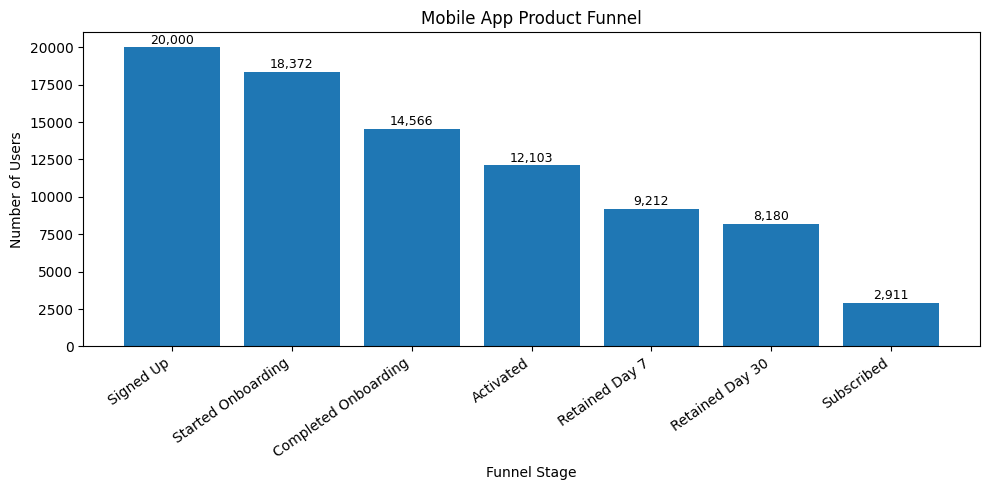

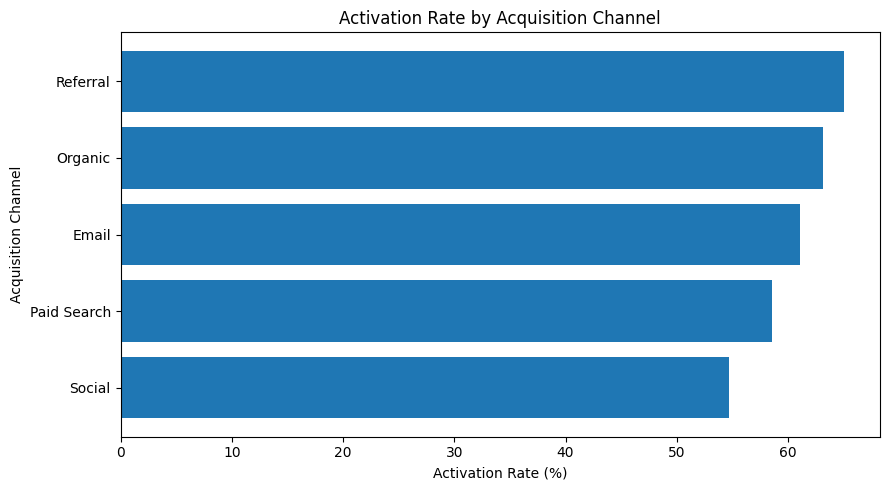

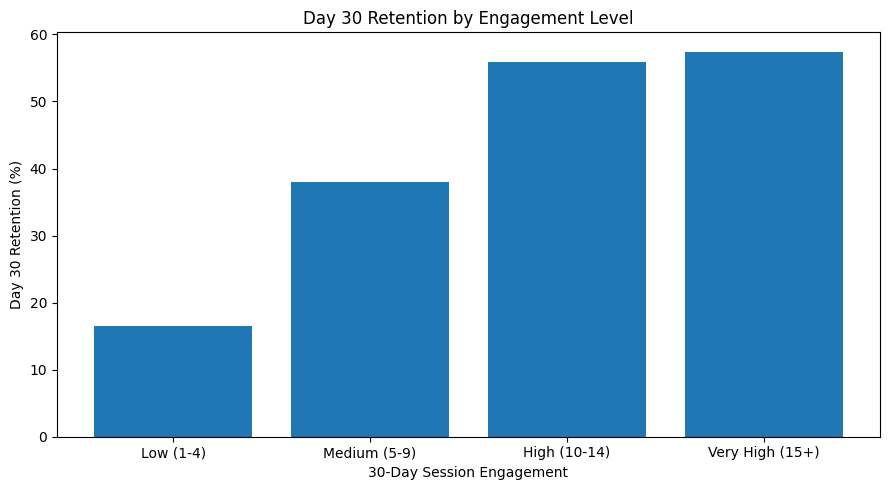

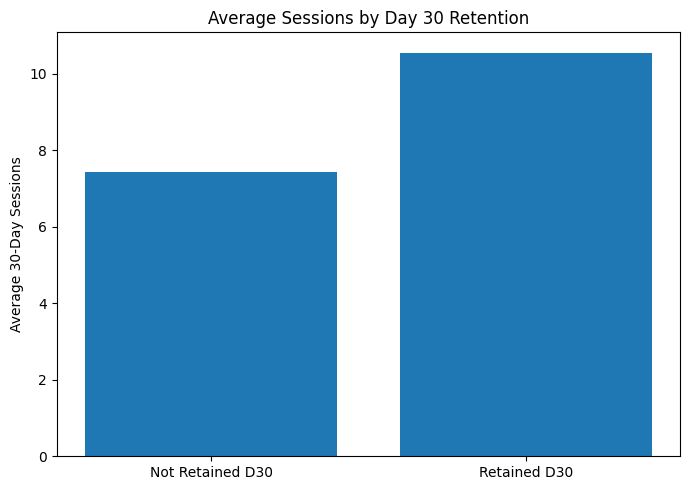


PHASE 3 SUMMARY
Largest funnel loss occurs before Subscribed: 5,269 users lost.
Highest D30 retention engagement group: Very High (15+) (57.44%).
D30 retained users average 10.55 sessions vs 7.43 for non-retained users.
D30 retained users use an average of 4.86 features vs 3.33 for non-retained users.

Phase 3 complete.


In [3]:
# PHASE 3: FUNNEL, ENGAGEMENT AND VISUALIZATION

# ---------------------------------------------------------
# Funnel drop-off analysis
# ---------------------------------------------------------

funnel_analysis = funnel.copy()

funnel_analysis["users_lost"] = (
    funnel_analysis["users"].shift(1) -
    funnel_analysis["users"]
)

funnel_analysis.loc[0, "users_lost"] = 0

funnel_analysis["dropoff_rate_%"] = (
    funnel_analysis["users_lost"] /
    funnel_analysis["users"].shift(1) * 100
).round(2)

funnel_analysis.loc[0, "dropoff_rate_%"] = 0

print("=" * 65)
print("FUNNEL DROP-OFF ANALYSIS")
print("=" * 65)

display(funnel_analysis)

# ---------------------------------------------------------
# Engagement by retention status
# ---------------------------------------------------------

retention_engagement = (
    users.groupby("retained_day_30")
    .agg(
        users=("user_id", "count"),
        avg_sessions=("sessions_30d", "mean"),
        avg_features=("features_used", "mean"),
        avg_session_minutes=("avg_session_minutes", "mean"),
        activation_rate=("activated", "mean"),
        subscription_rate=("subscribed", "mean"),
        avg_revenue=("revenue_30d", "mean")
    )
    .reset_index()
)

retention_engagement["retention_status"] = (
    retention_engagement["retained_day_30"]
    .map({
        0: "Not Retained D30",
        1: "Retained D30"
    })
)

retention_engagement["activation_rate"] = (
    retention_engagement["activation_rate"] * 100
).round(2)

retention_engagement["subscription_rate"] = (
    retention_engagement["subscription_rate"] * 100
).round(2)

for col in [
    "avg_sessions",
    "avg_features",
    "avg_session_minutes",
    "avg_revenue"
]:
    retention_engagement[col] = (
        retention_engagement[col].round(2)
    )

print("\n" + "=" * 65)
print("ENGAGEMENT BY D30 RETENTION")
print("=" * 65)

display(
    retention_engagement[
        [
            "retention_status",
            "users",
            "avg_sessions",
            "avg_features",
            "avg_session_minutes",
            "activation_rate",
            "subscription_rate",
            "avg_revenue"
        ]
    ]
)

# ---------------------------------------------------------
# Engagement bands
# ---------------------------------------------------------

users["engagement_level"] = pd.cut(
    users["sessions_30d"],
    bins=[0, 4, 9, 14, np.inf],
    labels=[
        "Low (1-4)",
        "Medium (5-9)",
        "High (10-14)",
        "Very High (15+)"
    ]
)

engagement_summary = (
    users.groupby(
        "engagement_level",
        observed=True
    )
    .agg(
        users=("user_id", "count"),
        activation_rate=("activated", "mean"),
        day_7_retention=("retained_day_7", "mean"),
        day_30_retention=("retained_day_30", "mean"),
        subscription_rate=("subscribed", "mean"),
        avg_revenue=("revenue_30d", "mean")
    )
    .reset_index()
)

for col in [
    "activation_rate",
    "day_7_retention",
    "day_30_retention",
    "subscription_rate"
]:
    engagement_summary[col] = (
        engagement_summary[col] * 100
    ).round(2)

engagement_summary["avg_revenue"] = (
    engagement_summary["avg_revenue"].round(2)
)

print("\n" + "=" * 65)
print("PERFORMANCE BY ENGAGEMENT LEVEL")
print("=" * 65)

display(engagement_summary)

# ---------------------------------------------------------
# Visualization 1: Product funnel
# ---------------------------------------------------------

plt.figure(figsize=(10, 5))

plt.bar(
    funnel["stage"],
    funnel["users"]
)

plt.title("Mobile App Product Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users")
plt.xticks(rotation=35, ha="right")

for i, value in enumerate(funnel["users"]):
    plt.text(
        i,
        value + 250,
        f"{value:,}",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization 2: Activation by acquisition channel
# ---------------------------------------------------------

channel_plot = channel_performance.sort_values(
    "activation_rate",
    ascending=True
)

plt.figure(figsize=(9, 5))

plt.barh(
    channel_plot["acquisition_channel"],
    channel_plot["activation_rate"]
)

plt.title("Activation Rate by Acquisition Channel")
plt.xlabel("Activation Rate (%)")
plt.ylabel("Acquisition Channel")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization 3: D30 retention by engagement level
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    engagement_summary["engagement_level"].astype(str),
    engagement_summary["day_30_retention"]
)

plt.title("Day 30 Retention by Engagement Level")
plt.xlabel("30-Day Session Engagement")
plt.ylabel("Day 30 Retention (%)")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization 4: Sessions by D30 retention
# ---------------------------------------------------------

retention_plot = (
    retention_engagement[
        ["retention_status", "avg_sessions"]
    ]
)

plt.figure(figsize=(7, 5))

plt.bar(
    retention_plot["retention_status"],
    retention_plot["avg_sessions"]
)

plt.title("Average Sessions by Day 30 Retention")
plt.ylabel("Average 30-Day Sessions")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Key findings
# ---------------------------------------------------------

largest_dropoff = funnel_analysis.iloc[1:].sort_values(
    "users_lost",
    ascending=False
).iloc[0]

highest_engagement = engagement_summary.sort_values(
    "day_30_retention",
    ascending=False
).iloc[0]

retained_metrics = retention_engagement[
    retention_engagement["retained_day_30"] == 1
].iloc[0]

not_retained_metrics = retention_engagement[
    retention_engagement["retained_day_30"] == 0
].iloc[0]

print("\n" + "=" * 65)
print("PHASE 3 SUMMARY")
print("=" * 65)

print(
    f"Largest funnel loss occurs before "
    f"{largest_dropoff['stage']}: "
    f"{int(largest_dropoff['users_lost']):,} users lost."
)

print(
    f"Highest D30 retention engagement group: "
    f"{highest_engagement['engagement_level']} "
    f"({highest_engagement['day_30_retention']:.2f}%)."
)

print(
    f"D30 retained users average "
    f"{retained_metrics['avg_sessions']:.2f} sessions "
    f"vs {not_retained_metrics['avg_sessions']:.2f} "
    f"for non-retained users."
)

print(
    f"D30 retained users use an average of "
    f"{retained_metrics['avg_features']:.2f} features "
    f"vs {not_retained_metrics['avg_features']:.2f} "
    f"for non-retained users."
)

print("\nPhase 3 complete.")

## Phase 4 — Cohort Retention Analysis

This phase groups users by signup month to compare activation and retention performance across acquisition cohorts.

MONTHLY SIGNUP COHORT PERFORMANCE


,signup_cohort,users,activation_rate,day_7_retention,day_30_retention,subscription_rate,avg_sessions,avg_features,total_revenue,revenue_per_user
0,2026-01,6992,60.31,46.34,40.80,14.65,8.67,3.95,30029.34,4.29
1,2026-02,6231,60.87,44.95,41.12,14.35,8.72,3.98,26668.99,4.28
2,2026-03,6777,60.40,46.79,40.80,14.65,8.72,3.93,29901.64,4.41



COHORT PERFORMANCE BY ACQUISITION CHANNEL


,signup_cohort,acquisition_channel,users,activation_rate,day_30_retention,subscription_rate
0,2026-01,Email,725,60.28,42.21,15.31
1,2026-01,Organic,2107,63.03,42.34,15.28
2,2026-01,Paid Search,1567,57.82,39.63,13.66
3,2026-01,Referral,1168,65.15,41.27,15.58
4,2026-01,Social,1425,55.09,38.74,13.68
5,2026-02,Email,610,59.84,38.85,15.25
6,2026-02,Organic,1887,63.86,43.14,15.10
7,2026-02,Paid Search,1429,59.55,40.73,15.40
8,2026-02,Referral,1023,65.40,42.52,13.20
9,2026-02,Social,1282,54.84,38.53,12.56



D30 RETENTION MATRIX (%)


acquisition_channel,Email,Organic,Paid Search,Referral,Social
signup_cohort,,,,,
2026-01,42.21,42.34,39.63,41.27,38.74
2026-02,38.85,43.14,40.73,42.52,38.53
2026-03,40.55,42.39,40.13,41.29,38.90


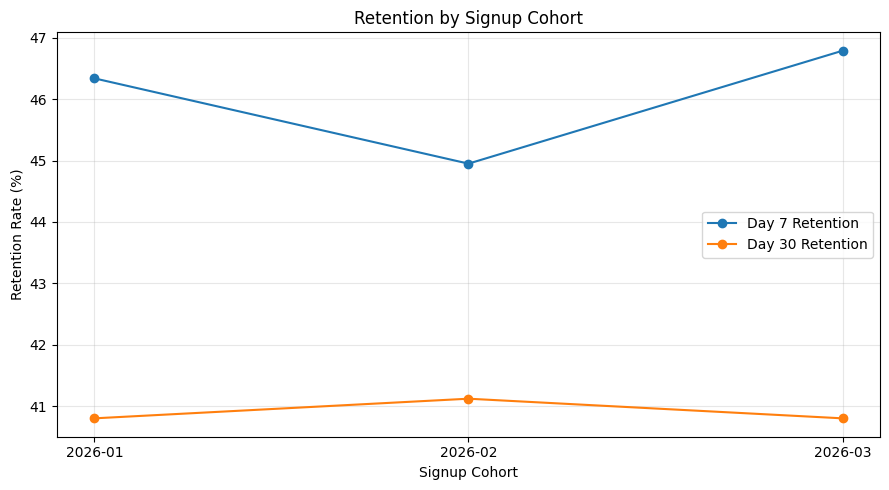

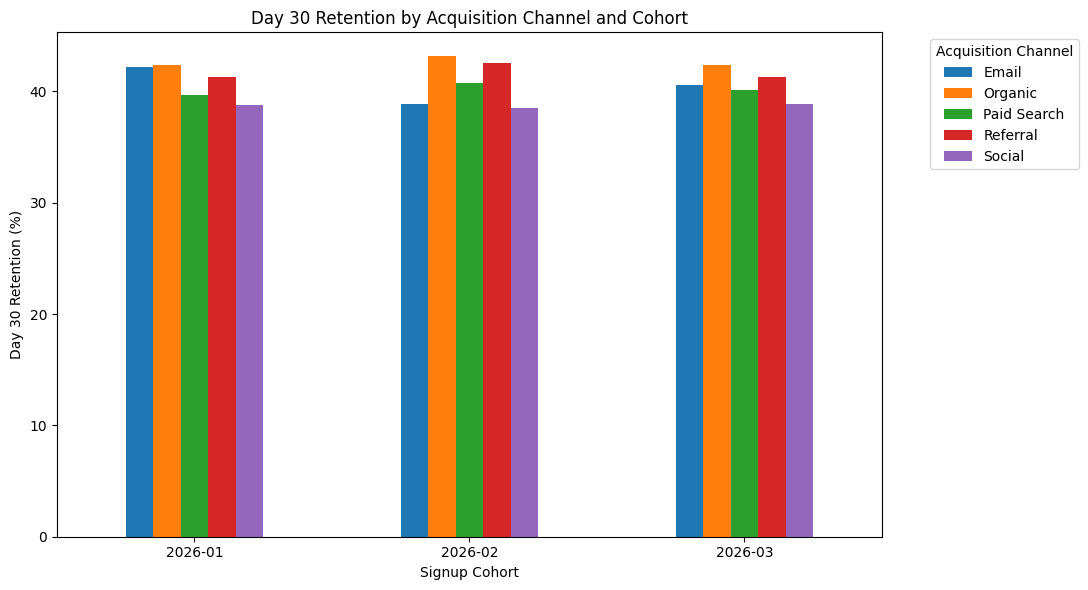


PHASE 4 SUMMARY
Highest D30 retention cohort: 2026-02 (41.12%)
Lowest D30 retention cohort: 2026-01 (40.80%)
Strongest cohort-channel combination: 2026-02 / Organic (43.14% D30 retention)
Overall D30 retention: 40.90%

Phase 4 complete.


In [4]:
# PHASE 4: COHORT RETENTION ANALYSIS

# ---------------------------------------------------------
# Create signup cohorts
# ---------------------------------------------------------

users["signup_cohort"] = (
    users["signup_date"]
    .dt.to_period("M")
    .astype(str)
)

cohort_summary = (
    users.groupby("signup_cohort")
    .agg(
        users=("user_id", "count"),
        activation_rate=("activated", "mean"),
        day_7_retention=("retained_day_7", "mean"),
        day_30_retention=("retained_day_30", "mean"),
        subscription_rate=("subscribed", "mean"),
        avg_sessions=("sessions_30d", "mean"),
        avg_features=("features_used", "mean"),
        total_revenue=("revenue_30d", "sum")
    )
    .reset_index()
)

for col in [
    "activation_rate",
    "day_7_retention",
    "day_30_retention",
    "subscription_rate"
]:
    cohort_summary[col] = (
        cohort_summary[col] * 100
    ).round(2)

cohort_summary["avg_sessions"] = (
    cohort_summary["avg_sessions"].round(2)
)

cohort_summary["avg_features"] = (
    cohort_summary["avg_features"].round(2)
)

cohort_summary["total_revenue"] = (
    cohort_summary["total_revenue"].round(2)
)

cohort_summary["revenue_per_user"] = (
    cohort_summary["total_revenue"] /
    cohort_summary["users"]
).round(2)

print("=" * 65)
print("MONTHLY SIGNUP COHORT PERFORMANCE")
print("=" * 65)

display(cohort_summary)

# ---------------------------------------------------------
# Cohort performance by acquisition channel
# ---------------------------------------------------------

cohort_channel = (
    users.groupby(
        ["signup_cohort", "acquisition_channel"]
    )
    .agg(
        users=("user_id", "count"),
        activation_rate=("activated", "mean"),
        day_30_retention=("retained_day_30", "mean"),
        subscription_rate=("subscribed", "mean")
    )
    .reset_index()
)

for col in [
    "activation_rate",
    "day_30_retention",
    "subscription_rate"
]:
    cohort_channel[col] = (
        cohort_channel[col] * 100
    ).round(2)

print("\n" + "=" * 65)
print("COHORT PERFORMANCE BY ACQUISITION CHANNEL")
print("=" * 65)

display(cohort_channel)

# ---------------------------------------------------------
# D30 retention matrix
# ---------------------------------------------------------

retention_matrix = (
    cohort_channel.pivot(
        index="signup_cohort",
        columns="acquisition_channel",
        values="day_30_retention"
    )
)

print("\n" + "=" * 65)
print("D30 RETENTION MATRIX (%)")
print("=" * 65)

display(retention_matrix.round(2))

# ---------------------------------------------------------
# Visualization: retention by signup cohort
# ---------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    cohort_summary["signup_cohort"],
    cohort_summary["day_7_retention"],
    marker="o",
    label="Day 7 Retention"
)

plt.plot(
    cohort_summary["signup_cohort"],
    cohort_summary["day_30_retention"],
    marker="o",
    label="Day 30 Retention"
)

plt.title("Retention by Signup Cohort")
plt.xlabel("Signup Cohort")
plt.ylabel("Retention Rate (%)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Visualization: D30 retention by channel and cohort
# ---------------------------------------------------------

retention_matrix.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Day 30 Retention by Acquisition Channel and Cohort")
plt.xlabel("Signup Cohort")
plt.ylabel("Day 30 Retention (%)")
plt.xticks(rotation=0)
plt.legend(
    title="Acquisition Channel",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Identify strongest and weakest cohorts
# ---------------------------------------------------------

best_cohort = cohort_summary.loc[
    cohort_summary["day_30_retention"].idxmax()
]

lowest_cohort = cohort_summary.loc[
    cohort_summary["day_30_retention"].idxmin()
]

best_cohort_channel = cohort_channel.loc[
    cohort_channel["day_30_retention"].idxmax()
]

print("\n" + "=" * 65)
print("PHASE 4 SUMMARY")
print("=" * 65)

print(
    f"Highest D30 retention cohort: "
    f"{best_cohort['signup_cohort']} "
    f"({best_cohort['day_30_retention']:.2f}%)"
)

print(
    f"Lowest D30 retention cohort: "
    f"{lowest_cohort['signup_cohort']} "
    f"({lowest_cohort['day_30_retention']:.2f}%)"
)

print(
    f"Strongest cohort-channel combination: "
    f"{best_cohort_channel['signup_cohort']} / "
    f"{best_cohort_channel['acquisition_channel']} "
    f"({best_cohort_channel['day_30_retention']:.2f}% D30 retention)"
)

print(
    f"Overall D30 retention: "
    f"{users['retained_day_30'].mean():.2%}"
)

print("\nPhase 4 complete.")

## Phase 5 — A/B Testing and Experiment Analysis

This phase evaluates an onboarding experiment by comparing the Control and Treatment groups. Two-proportion z-tests and confidence intervals are used to determine whether observed differences are statistically significant.

A/B TEST — CONTROL VS TREATMENT


,experiment_group,users
0,Treatment,10082
1,Control,9918



EXPERIMENT PERFORMANCE


,experiment_group,users,onboarding_completion,activation_rate,day_7_retention,day_30_retention,subscription_rate,avg_sessions,avg_revenue,total_revenue
0,Control,9918,69.96,59.87,45.61,40.57,14.18,8.67,4.12,40861.36
1,Treatment,10082,75.65,61.15,46.50,41.22,14.93,8.73,4.54,45738.61



STATISTICAL TEST RESULTS


,metric,control_rate_%,treatment_rate_%,absolute_lift_pp,relative_lift_%,z_statistic,p_value,ci_lower_pp,ci_upper_pp,significant_5pct
0,onboarding_completed,69.9637,75.6497,5.6860,8.1270,9.0381,0.0000,4.4548,6.9172,True
1,activated,59.8709,61.1486,1.2776,2.1340,1.8481,0.0646,-0.0773,2.6325,False
2,retained_day_7,45.6140,46.4987,0.8847,1.9395,1.2550,0.2095,-0.4969,2.2662,False
3,retained_day_30,40.5727,41.2220,0.6493,1.6003,0.9338,0.3504,-0.7135,2.0120,False
4,subscribed,14.1762,14.9276,0.7513,5.3001,1.5065,0.1319,-0.2259,1.7286,False


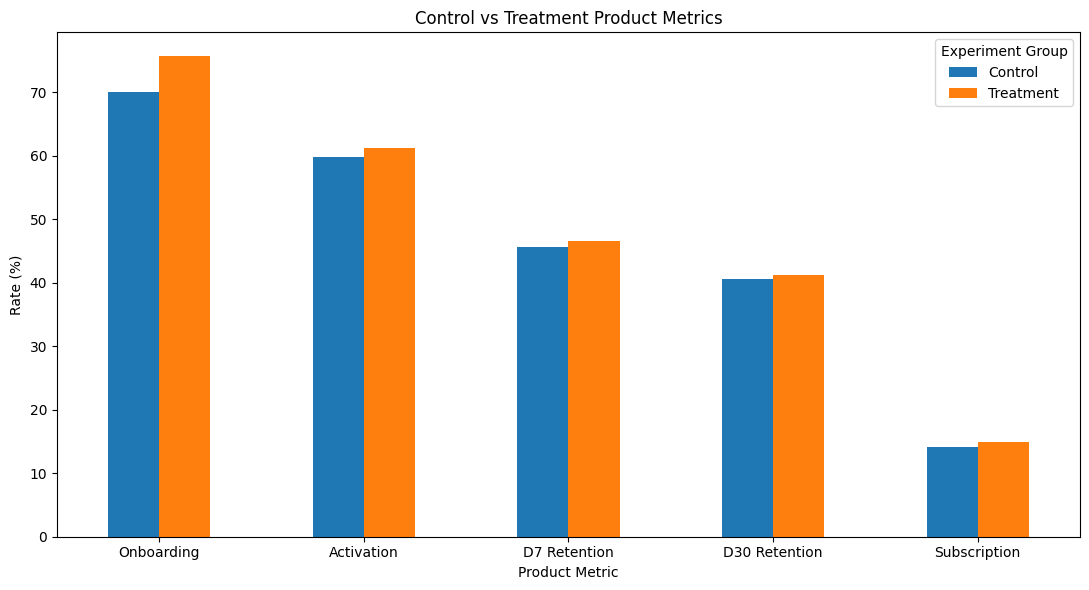


PHASE 5 SUMMARY
Onboarding Completed: Control 69.96% vs Treatment 75.65% | Lift 5.69 pp (8.13% relative) | p=0.0000 | statistically significant
Activated: Control 59.87% vs Treatment 61.15% | Lift 1.28 pp (2.13% relative) | p=0.0646 | not statistically significant
Retained Day 7: Control 45.61% vs Treatment 46.50% | Lift 0.88 pp (1.94% relative) | p=0.2095 | not statistically significant
Retained Day 30: Control 40.57% vs Treatment 41.22% | Lift 0.65 pp (1.60% relative) | p=0.3504 | not statistically significant
Subscribed: Control 14.18% vs Treatment 14.93% | Lift 0.75 pp (5.30% relative) | p=0.1319 | not statistically significant

Main experiment outcome:
The Treatment onboarding experience changed completion from 69.96% to 75.65%.
Absolute lift: 5.69 percentage points.
Relative lift: 8.13%.
95% confidence interval for the absolute difference: [4.45, 6.92] percentage points.
P-value: 0.0000

Phase 5 complete.


In [5]:
# PHASE 5: A/B TESTING AND STATISTICAL SIGNIFICANCE

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import norm

print("=" * 70)
print("A/B TEST — CONTROL VS TREATMENT")
print("=" * 70)

# ---------------------------------------------------------
# Experiment group sizes
# ---------------------------------------------------------

experiment_sizes = (
    users["experiment_group"]
    .value_counts()
    .rename_axis("experiment_group")
    .reset_index(name="users")
)

display(experiment_sizes)

# ---------------------------------------------------------
# Experiment performance summary
# ---------------------------------------------------------

experiment_summary = (
    users.groupby("experiment_group")
    .agg(
        users=("user_id", "count"),
        onboarding_completion=("onboarding_completed", "mean"),
        activation_rate=("activated", "mean"),
        day_7_retention=("retained_day_7", "mean"),
        day_30_retention=("retained_day_30", "mean"),
        subscription_rate=("subscribed", "mean"),
        avg_sessions=("sessions_30d", "mean"),
        avg_revenue=("revenue_30d", "mean"),
        total_revenue=("revenue_30d", "sum")
    )
    .reset_index()
)

rate_columns = [
    "onboarding_completion",
    "activation_rate",
    "day_7_retention",
    "day_30_retention",
    "subscription_rate"
]

display_summary = experiment_summary.copy()

for col in rate_columns:
    display_summary[col] = (
        display_summary[col] * 100
    ).round(2)

display_summary["avg_sessions"] = (
    display_summary["avg_sessions"].round(2)
)

display_summary["avg_revenue"] = (
    display_summary["avg_revenue"].round(2)
)

display_summary["total_revenue"] = (
    display_summary["total_revenue"].round(2)
)

print("\nEXPERIMENT PERFORMANCE")
display(display_summary)

# ---------------------------------------------------------
# Function for two-proportion A/B test
# ---------------------------------------------------------

def ab_proportion_test(data, metric):

    control = data[
        data["experiment_group"] == "Control"
    ][metric]

    treatment = data[
        data["experiment_group"] == "Treatment"
    ][metric]

    control_success = control.sum()
    treatment_success = treatment.sum()

    control_n = len(control)
    treatment_n = len(treatment)

    control_rate = control.mean()
    treatment_rate = treatment.mean()

    count = np.array([
        treatment_success,
        control_success
    ])

    nobs = np.array([
        treatment_n,
        control_n
    ])

    z_stat, p_value = proportions_ztest(
        count,
        nobs
    )

    absolute_lift = treatment_rate - control_rate

    relative_lift = (
        absolute_lift / control_rate
        if control_rate != 0 else np.nan
    )

    # Standard error for difference in proportions
    se_difference = np.sqrt(
        treatment_rate * (1 - treatment_rate) / treatment_n +
        control_rate * (1 - control_rate) / control_n
    )

    z_critical = norm.ppf(0.975)

    ci_lower = absolute_lift - z_critical * se_difference
    ci_upper = absolute_lift + z_critical * se_difference

    return {
        "metric": metric,
        "control_rate_%": control_rate * 100,
        "treatment_rate_%": treatment_rate * 100,
        "absolute_lift_pp": absolute_lift * 100,
        "relative_lift_%": relative_lift * 100,
        "z_statistic": z_stat,
        "p_value": p_value,
        "ci_lower_pp": ci_lower * 100,
        "ci_upper_pp": ci_upper * 100,
        "significant_5pct": p_value < 0.05
    }

# ---------------------------------------------------------
# Test important product metrics
# ---------------------------------------------------------

metrics_to_test = [
    "onboarding_completed",
    "activated",
    "retained_day_7",
    "retained_day_30",
    "subscribed"
]

ab_results = pd.DataFrame(
    [
        ab_proportion_test(users, metric)
        for metric in metrics_to_test
    ]
)

numeric_cols = [
    "control_rate_%",
    "treatment_rate_%",
    "absolute_lift_pp",
    "relative_lift_%",
    "z_statistic",
    "p_value",
    "ci_lower_pp",
    "ci_upper_pp"
]

ab_results[numeric_cols] = (
    ab_results[numeric_cols].round(4)
)

print("\n" + "=" * 70)
print("STATISTICAL TEST RESULTS")
print("=" * 70)

display(ab_results)

# ---------------------------------------------------------
# Visualization of experiment performance
# ---------------------------------------------------------

plot_metrics = [
    "onboarding_completion",
    "activation_rate",
    "day_7_retention",
    "day_30_retention",
    "subscription_rate"
]

plot_data = (
    experiment_summary
    .set_index("experiment_group")[plot_metrics]
    .T * 100
)

plot_data.index = [
    "Onboarding",
    "Activation",
    "D7 Retention",
    "D30 Retention",
    "Subscription"
]

plot_data.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Control vs Treatment Product Metrics")
plt.ylabel("Rate (%)")
plt.xlabel("Product Metric")
plt.xticks(rotation=0)
plt.legend(title="Experiment Group")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Experiment interpretation
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 5 SUMMARY")
print("=" * 70)

for _, row in ab_results.iterrows():

    metric_name = (
        row["metric"]
        .replace("_", " ")
        .title()
    )

    significance = (
        "statistically significant"
        if row["significant_5pct"]
        else "not statistically significant"
    )

    print(
        f"{metric_name}: "
        f"Control {row['control_rate_%']:.2f}% vs "
        f"Treatment {row['treatment_rate_%']:.2f}% | "
        f"Lift {row['absolute_lift_pp']:.2f} pp "
        f"({row['relative_lift_%']:.2f}% relative) | "
        f"p={row['p_value']:.4f} | "
        f"{significance}"
    )

# Main experiment outcome
onboarding_result = ab_results[
    ab_results["metric"] == "onboarding_completed"
].iloc[0]

print("\nMain experiment outcome:")

print(
    f"The Treatment onboarding experience changed completion "
    f"from {onboarding_result['control_rate_%']:.2f}% "
    f"to {onboarding_result['treatment_rate_%']:.2f}%."
)

print(
    f"Absolute lift: "
    f"{onboarding_result['absolute_lift_pp']:.2f} percentage points."
)

print(
    f"Relative lift: "
    f"{onboarding_result['relative_lift_%']:.2f}%."
)

print(
    f"95% confidence interval for the absolute difference: "
    f"[{onboarding_result['ci_lower_pp']:.2f}, "
    f"{onboarding_result['ci_upper_pp']:.2f}] percentage points."
)

print(
    f"P-value: "
    f"{onboarding_result['p_value']:.4f}"
)

print("\nPhase 5 complete.")

## Phase 6 — Day 30 Retention Prediction

This phase builds machine learning models to identify users at risk of not returning by Day 30. Logistic Regression and Random Forest are compared using early user behavior and product engagement indicators.

DAY 30 RETENTION PREDICTION
Modeling observations: 20,000
Predictors: 9
D30 retained users: 8,180
D30 retention rate: 40.90%

Training observations: 15,000
Testing observations: 5,000

MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.7374,0.7013,0.6235,0.6601,0.7918
1,Random Forest,0.7346,0.6922,0.6323,0.6609,0.7891



Best model by ROC-AUC: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0      0.758     0.816     0.786      2955
           1      0.701     0.623     0.660      2045

    accuracy                          0.737      5000
   macro avg      0.730     0.720     0.723      5000
weighted avg      0.735     0.737     0.735      5000



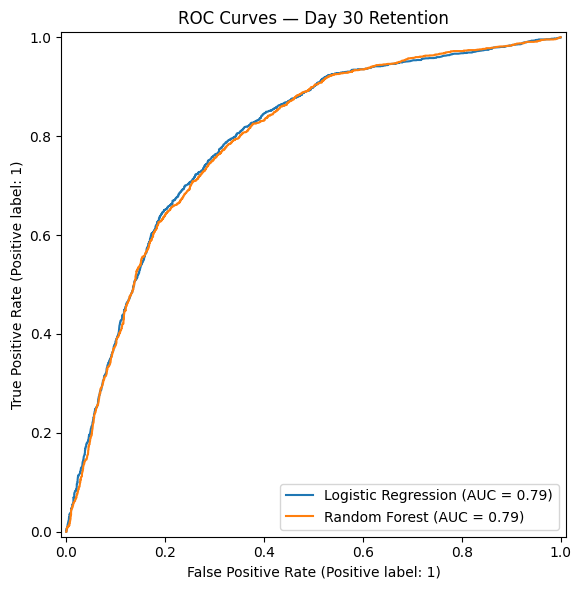

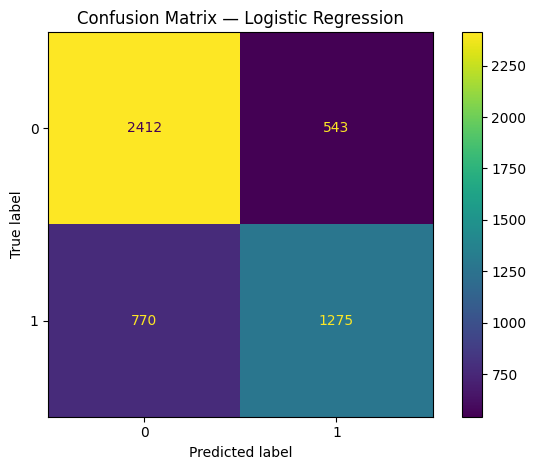


TOP RANDOM FOREST FEATURES


,feature,importance
0,retained_day_7,0.464698
1,activated,0.241692
2,features_used,0.162439
3,onboarding_completed,0.029334
4,country_United States,0.008681
5,experiment_group_Control,0.008334
6,experiment_group_Treatment,0.008243
7,onboarding_started,0.007216
8,platform_iOS,0.007092
9,acquisition_channel_Paid Search,0.007005


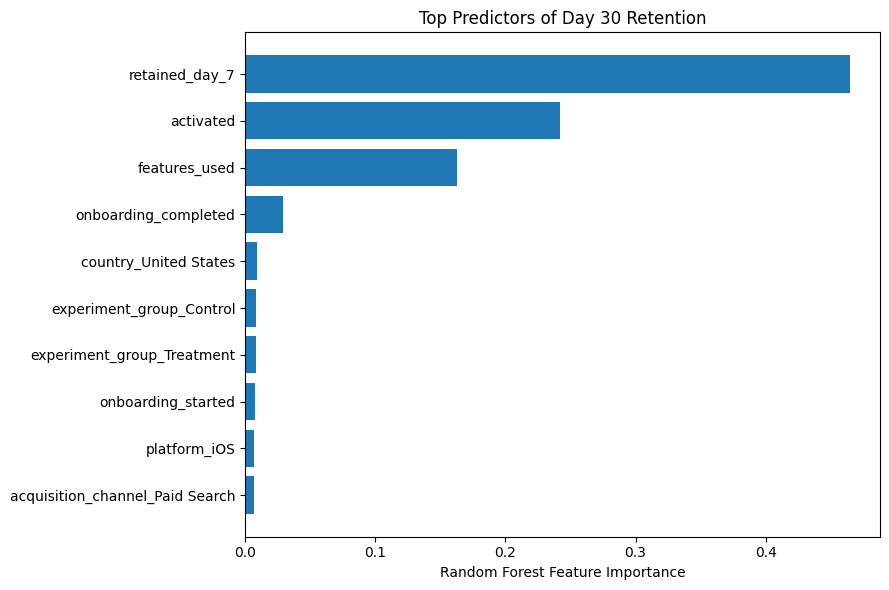


RETENTION RISK SEGMENTS


,retention_risk,users,actual_d30_retention,avg_predicted_probability
0,High Risk,7527,13.06,14.03
1,Medium Risk,5019,40.05,36.22
2,Low Risk,7454,69.59,70.71



PHASE 6 SUMMARY
Best model: Logistic Regression
ROC-AUC: 0.7918
F1 score: 0.6601
Recall: 0.6235
Most important Random Forest predictor: retained_day_7 (46.47% importance)
High-risk users identified: 7,527

Phase 6 complete.


In [6]:
# PHASE 6: DAY 30 RETENTION PREDICTION

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

print("=" * 70)
print("DAY 30 RETENTION PREDICTION")
print("=" * 70)

# ---------------------------------------------------------
# Select predictors
# ---------------------------------------------------------
# The model uses user characteristics and engagement
# indicators available before the D30 outcome.
# Target leakage variables such as retained_day_30,
# subscribed, revenue_30d, and last_activity_date are excluded.

features = [
    "platform",
    "acquisition_channel",
    "country",
    "experiment_group",
    "onboarding_started",
    "onboarding_completed",
    "activated",
    "features_used",
    "retained_day_7"
]

target = "retained_day_30"

X = users[features].copy()
y = users[target].copy()

categorical_features = [
    "platform",
    "acquisition_channel",
    "country",
    "experiment_group"
]

numeric_features = [
    "onboarding_started",
    "onboarding_completed",
    "activated",
    "features_used",
    "retained_day_7"
]

print(f"Modeling observations: {len(X):,}")
print(f"Predictors: {len(features)}")
print(f"D30 retained users: {y.sum():,}")
print(f"D30 retention rate: {y.mean():.2%}")

# ---------------------------------------------------------
# Train/test split
# ---------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"\nTraining observations: {len(X_train):,}")
print(f"Testing observations: {len(X_test):,}")

# ---------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        )
    ]
)

# ---------------------------------------------------------
# Logistic Regression
# ---------------------------------------------------------

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

log_pred = logistic_model.predict(X_test)
log_prob = logistic_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# Random Forest
# ---------------------------------------------------------

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=250,
                max_depth=10,
                min_samples_leaf=8,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# Evaluation function
# ---------------------------------------------------------

def evaluate_model(
    model_name,
    y_true,
    predictions,
    probabilities
):

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions
        ),
        "Recall": recall_score(
            y_true,
            predictions
        ),
        "F1": f1_score(
            y_true,
            predictions
        ),
        "ROC_AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        log_pred,
        log_prob
    ),
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
])

for col in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC"
]:
    results[col] = results[col].round(4)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(results)

# ---------------------------------------------------------
# Classification report for best ROC-AUC model
# ---------------------------------------------------------

best_model_name = results.loc[
    results["ROC_AUC"].idxmax(),
    "Model"
]

if best_model_name == "Random Forest":
    best_pred = rf_pred
    best_prob = rf_prob
    best_pipeline = rf_model
else:
    best_pred = log_pred
    best_prob = log_prob
    best_pipeline = logistic_model

print(
    f"\nBest model by ROC-AUC: "
    f"{best_model_name}"
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        best_pred,
        digits=3
    )
)

# ---------------------------------------------------------
# ROC curve comparison
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    log_prob,
    name="Logistic Regression",
    ax=plt.gca()
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name="Random Forest",
    ax=plt.gca()
)

plt.title("ROC Curves — Day 30 Retention")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Confusion matrix for best model
# ---------------------------------------------------------

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Random Forest feature importance
# ---------------------------------------------------------

rf_preprocessor = rf_model.named_steps[
    "preprocessor"
]

encoded_categories = (
    rf_preprocessor
    .named_transformers_["categorical"]
    .get_feature_names_out(
        categorical_features
    )
)

all_feature_names = np.concatenate([
    encoded_categories,
    numeric_features
])

rf_importance = pd.DataFrame({
    "feature": all_feature_names,
    "importance":
        rf_model.named_steps[
            "model"
        ].feature_importances_
})

rf_importance = (
    rf_importance
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("TOP RANDOM FOREST FEATURES")
print("=" * 70)

display(rf_importance.head(12))

# ---------------------------------------------------------
# Feature importance visualization
# ---------------------------------------------------------

top_features = (
    rf_importance
    .head(10)
    .sort_values("importance")
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.title(
    "Top Predictors of Day 30 Retention"
)
plt.xlabel("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Retention risk scoring
# ---------------------------------------------------------

users_model = users.copy()

users_model["predicted_d30_retention_probability"] = (
    best_pipeline.predict_proba(X)[:, 1]
)

users_model["retention_risk"] = pd.cut(
    users_model[
        "predicted_d30_retention_probability"
    ],
    bins=[
        -np.inf,
        0.30,
        0.60,
        np.inf
    ],
    labels=[
        "High Risk",
        "Medium Risk",
        "Low Risk"
    ]
)

risk_summary = (
    users_model.groupby(
        "retention_risk",
        observed=True
    )
    .agg(
        users=("user_id", "count"),
        actual_d30_retention=(
            "retained_day_30",
            "mean"
        ),
        avg_predicted_probability=(
            "predicted_d30_retention_probability",
            "mean"
        )
    )
    .reset_index()
)

risk_summary["actual_d30_retention"] = (
    risk_summary[
        "actual_d30_retention"
    ] * 100
).round(2)

risk_summary[
    "avg_predicted_probability"
] = (
    risk_summary[
        "avg_predicted_probability"
    ] * 100
).round(2)

print("\n" + "=" * 70)
print("RETENTION RISK SEGMENTS")
print("=" * 70)

display(risk_summary)

# ---------------------------------------------------------
# Final Phase 6 summary
# ---------------------------------------------------------

best_result = results[
    results["Model"] == best_model_name
].iloc[0]

top_predictor = rf_importance.iloc[0]

print("\n" + "=" * 70)
print("PHASE 6 SUMMARY")
print("=" * 70)

print(
    f"Best model: {best_model_name}"
)

print(
    f"ROC-AUC: "
    f"{best_result['ROC_AUC']:.4f}"
)

print(
    f"F1 score: "
    f"{best_result['F1']:.4f}"
)

print(
    f"Recall: "
    f"{best_result['Recall']:.4f}"
)

print(
    f"Most important Random Forest predictor: "
    f"{top_predictor['feature']} "
    f"({top_predictor['importance']:.2%} importance)"
)

high_risk = risk_summary[
    risk_summary["retention_risk"] == "High Risk"
]

if len(high_risk) > 0:
    print(
        f"High-risk users identified: "
        f"{int(high_risk.iloc[0]['users']):,}"
    )

print("\nPhase 6 complete.")

## Phase 7 — Business Insights and Recommendations

The final phase combines the funnel, engagement, experimentation, cohort, and predictive modeling results into actionable product recommendations.

In [7]:
# PHASE 7: FINAL BUSINESS INSIGHTS AND RECOMMENDATIONS

print("=" * 75)
print("FINAL PROJECT SUMMARY")
print("=" * 75)

print(f"""
DATASET
-------
Users analyzed: {len(users):,}
Signup period: {users['signup_date'].min().date()} to {users['signup_date'].max().date()}

CORE PRODUCT METRICS
--------------------
Onboarding completion: {users['onboarding_completed'].mean():.2%}
Activation rate: {users['activated'].mean():.2%}
Day 7 retention: {users['retained_day_7'].mean():.2%}
Day 30 retention: {users['retained_day_30'].mean():.2%}
Subscription rate: {users['subscribed'].mean():.2%}
30-day revenue: ${users['revenue_30d'].sum():,.2f}

ENGAGEMENT
----------
Activated users D30 retention: 56.41%
Non-activated users D30 retention: 17.13%
Retention difference: 39.28 percentage points

Very-high-engagement users D30 retention: 57.44%
Low-engagement users D30 retention: 16.54%

EXPERIMENT
----------
Control onboarding completion: 69.96%
Treatment onboarding completion: 75.65%
Absolute lift: +5.69 percentage points
Relative lift: +8.13%
95% CI: [4.45, 6.92] percentage points
Result: Statistically significant

RETENTION MODEL
---------------
Best model: Logistic Regression
ROC-AUC: 0.7918
F1 score: 0.6601
High-risk users identified: 7,527
Strongest Random Forest predictor: Day 7 retention
""")

print("=" * 75)
print("BUSINESS RECOMMENDATIONS")
print("=" * 75)

recommendations = [
    (
        "1. Adopt the improved onboarding experience",
        "The Treatment experience produced a statistically significant "
        "5.69 percentage-point increase in onboarding completion. "
        "This supports rolling out the improved onboarding flow while "
        "continuing to monitor downstream retention and subscription metrics."
    ),

    (
        "2. Make activation a primary product KPI",
        "Activated users showed substantially higher Day 30 retention "
        "than non-activated users. Product teams should identify and "
        "promote the actions that help new users reach activation quickly."
    ),

    (
        "3. Focus retention efforts during the first week",
        "Day 7 retention was the strongest predictor of Day 30 retention. "
        "Lifecycle messaging, reminders, and personalized product guidance "
        "should focus heavily on the first seven days after signup."
    ),

    (
        "4. Increase feature discovery",
        "Retained users interacted with more product features than users "
        "who did not return by Day 30. In-app education and contextual "
        "feature recommendations could encourage deeper product adoption."
    ),

    (
        "5. Prioritize high-risk users",
        "The retention model identified 7,527 high-risk users. "
        "These users can be targeted with re-engagement campaigns, "
        "personalized recommendations, or onboarding assistance."
    ),

    (
        "6. Invest in higher-quality acquisition channels",
        "Referral produced the highest overall activation rate, while "
        "Organic users showed strong retention performance. Acquisition "
        "decisions should consider downstream activation and retention, "
        "not only signup volume."
    ),

    (
        "7. Continue experimentation on downstream outcomes",
        "The Treatment significantly improved onboarding completion, "
        "but improvements in activation, retention, and subscription "
        "were not statistically significant. Future experiments should "
        "target these downstream behaviors directly."
    )
]

for title, explanation in recommendations:
    print(f"\n{title}")
    print(explanation)

print("\n" + "=" * 75)
print("PROJECT CONCLUSION")
print("=" * 75)

print("""
The analysis shows that early product engagement is strongly associated
with long-term retention. Activation, first-week retention, and broader
feature adoption distinguish users who remain active through Day 30.

The onboarding experiment successfully improved completion, but the
downstream metrics did not show statistically significant improvements,
highlighting the importance of evaluating experiments beyond the
immediate conversion metric.

Finally, the retention model provides a practical framework for
identifying users who may benefit from targeted engagement strategies.
Together, the funnel, cohort, experiment, and predictive analyses provide
a product analytics framework for improving activation and retention.
""")

print("=" * 75)
print("PROJECT COMPLETE")
print("=" * 75)

FINAL PROJECT SUMMARY

DATASET
-------
Users analyzed: 20,000
Signup period: 2026-01-01 to 2026-03-31

CORE PRODUCT METRICS
--------------------
Onboarding completion: 72.83%
Activation rate: 60.51%
Day 7 retention: 46.06%
Day 30 retention: 40.90%
Subscription rate: 14.56%
30-day revenue: $86,599.97

ENGAGEMENT
----------
Activated users D30 retention: 56.41%
Non-activated users D30 retention: 17.13%
Retention difference: 39.28 percentage points

Very-high-engagement users D30 retention: 57.44%
Low-engagement users D30 retention: 16.54%

EXPERIMENT
----------
Control onboarding completion: 69.96%
Treatment onboarding completion: 75.65%
Absolute lift: +5.69 percentage points
Relative lift: +8.13%
95% CI: [4.45, 6.92] percentage points
Result: Statistically significant

RETENTION MODEL
---------------
Best model: Logistic Regression
ROC-AUC: 0.7918
F1 score: 0.6601
High-risk users identified: 7,527
Strongest Random Forest predictor: Day 7 retention

BUSINESS RECOMMENDATIONS

1. Adopt the